# Project: Milestone 5 - Merging the Data and Storing in a Database/Visualizing Data 

In [248]:
import pandas as pd
import sqlite3

# Step 2: Load Cleaned CSV Files
seasons_df = pd.read_csv("C:/Users/gjose/DSC540-T303/Seasons_Cleaned.csv")
standings_df = pd.read_csv("C:/Users/gjose/DSC540-T303/NBA_Standings_Cleaned.csv")
api_df = pd.read_csv("C:/Users/gjose/DSC540-T303/NBA_API_Games_Cleaned.csv")

# Normalize team names to lowercase
seasons_df['team'] = seasons_df['tm'].str.lower().str.strip()
standings_df['team'] = standings_df['team'].str.lower().str.strip()
api_df['home_team'] = api_df['home_team'].str.lower().str.strip()
api_df['visitor_team'] = api_df['visitor_team'].str.lower().str.strip()

# Map abbreviations to full team names
team_abbr_map = {
    'NYK': 'new york knicks',
    'MEM': 'memphis grizzlies',
    'OKC': 'oklahoma city thunder',
    'MIN': 'minnesota timberwolves',
    'TOT': None,
    'GSW': 'golden state warriors',
    'BOS': 'boston celtics',
    'LAL': 'los angeles lakers',
    'MIA': 'miami heat',
    'CHI': 'chicago bulls',
}

# Add full team name to seasons_df for joining
seasons_df['team_name'] = seasons_df['tm'].map(team_abbr_map)
seasons_df['team_name'] = seasons_df['team_name'].str.lower().str.strip()

# Step 3: Create SQLite DB & Save Tables
conn = sqlite3.connect("nba_final_project.db")

seasons_df.to_sql("season_stats", conn, if_exists="replace", index=False)
standings_df.to_sql("team_standings", conn, if_exists="replace", index=False)
api_df.to_sql("game_results", conn, if_exists="replace", index=False)


49

In [250]:

query = '''
SELECT
    s.player, s.tm AS team, s.year, s.pts, s.ast, s.trb,
    g.date, g.home_team, g.visitor_team, g.point_diff,
    t.win_pct
FROM season_stats s
LEFT JOIN game_results g ON s.year = g.season
LEFT JOIN team_standings t ON s.tm = t.team
LIMIT 500
'''
joined_df = pd.read_sql(query, conn)
joined_df.head()


,player,team,year,pts,ast,trb,date,home_team,visitor_team,point_diff,win_pct
0,Curly Armstrong,FTW,1950.0,458.0,176.0,NaN,None,None,None,None,None
1,Cliff Barker,INO,1950.0,279.0,109.0,NaN,None,None,None,None,None
2,Leo Barnhorst,CHS,1950.0,438.0,140.0,NaN,None,None,None,None,None
3,Ed Bartels,TOT,1950.0,63.0,20.0,NaN,None,None,None,None,None
4,Ed Bartels,DNN,1950.0,59.0,20.0,NaN,None,None,None,None,None


## Visualizations

### Distribution of Player Points

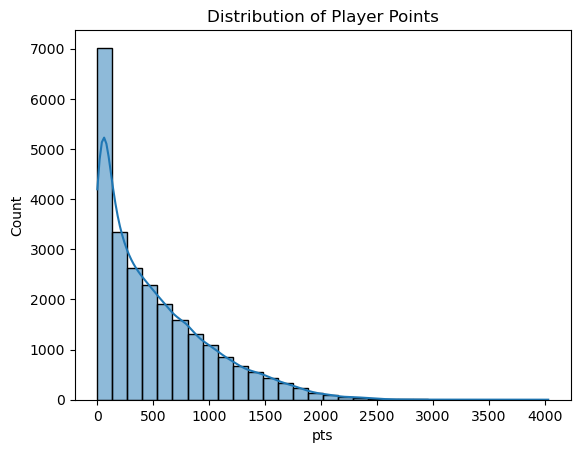

In [254]:
sns.histplot(seasons_df['pts'], bins=30, kde=True)
plt.title('Distribution of Player Points')
plt.show()

### Win % by Team

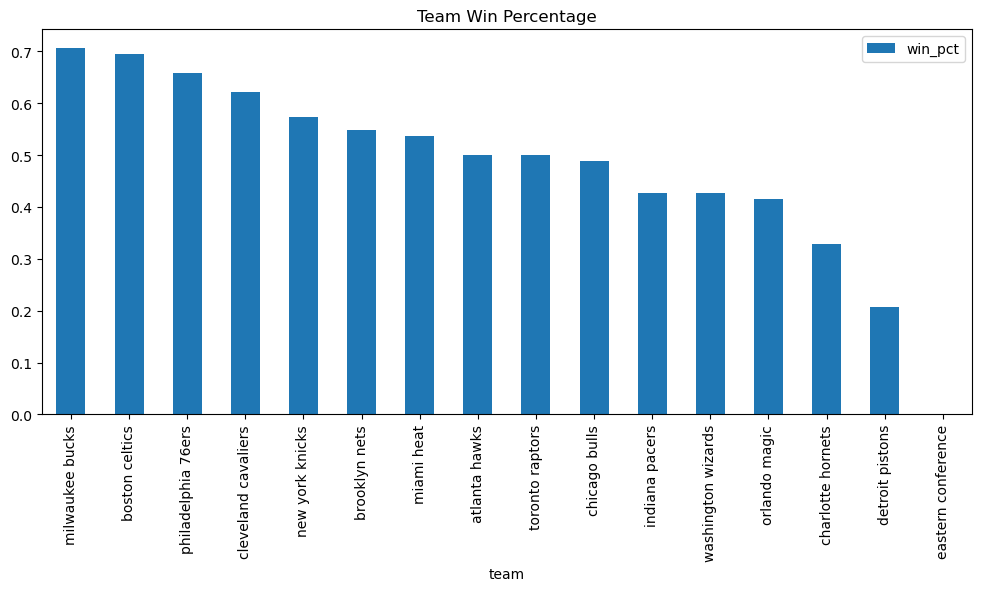

In [257]:
standings_df['win_pct'] = pd.to_numeric(standings_df['win_pct'], errors='coerce')

standings_df.sort_values('win_pct', ascending=False).plot(x='team', y='win_pct', kind='bar', figsize=(12,5))
plt.title('Team Win Percentage')
plt.xticks(rotation=90)
plt.show()

### Game Point Differential

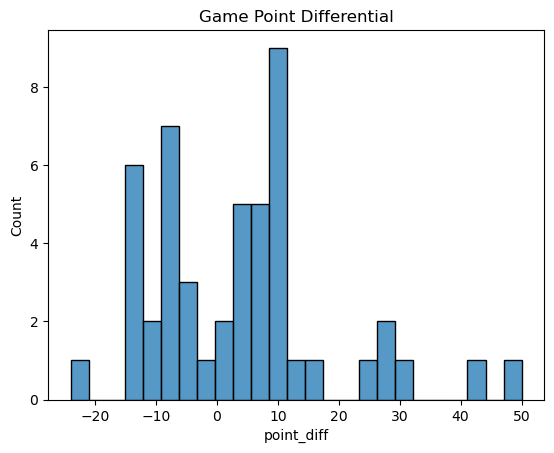

In [260]:
sns.histplot(api_df['point_diff'], bins=25)
plt.title('Game Point Differential')
plt.show()

### Top 10 Teams by Average Points

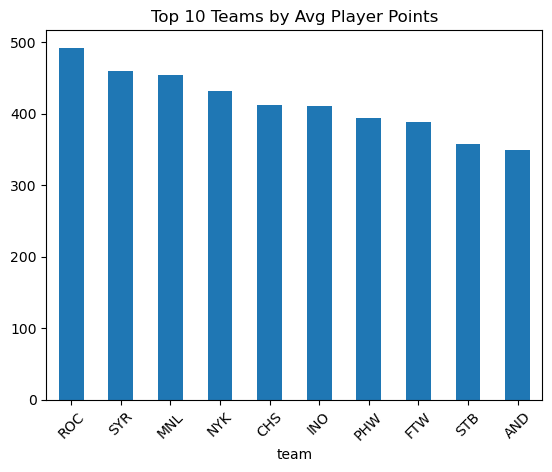

In [263]:
joined_df.groupby('team')['pts'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Teams by Avg Player Points')
plt.xticks(rotation=45)
plt.show()

### Player Points vs Team Win %

In [266]:
pd.read_sql("PRAGMA table_info(season_stats);", conn)


,cid,name,type,notnull,dflt_value,pk
0,0,unnamed:_0,INTEGER,0,None,0
1,1,year,REAL,0,None,0
2,2,player,TEXT,0,None,0
3,3,pos,TEXT,0,None,0
4,4,age,REAL,0,None,0
5,5,tm,TEXT,0,None,0
6,6,g,REAL,0,None,0
7,7,gs,REAL,0,None,0
8,8,mp,REAL,0,None,0
9,9,per,REAL,0,None,0


In [268]:
query = '''
SELECT
    s.player, s.team_name AS team, s.year, s.pts, s.ast, s.trb,
    g.date, g.home_team, g.visitor_team, g.point_diff,
    t.win_pct
FROM season_stats s
LEFT JOIN game_results g ON s.team_name = g.home_team
LEFT JOIN team_standings t ON s.team_name = t.team
WHERE s.year >= 2015
LIMIT 500
'''

joined_df = pd.read_sql(query, conn)
joined_df.head()





,player,team,year,pts,ast,trb,date,home_team,visitor_team,point_diff,win_pct
0,Quincy Acy,new york knicks,2015.0,398.0,68.0,301.0,None,None,None,NaN,0.573
1,Jordan Adams,memphis grizzlies,2015.0,94.0,16.0,28.0,2023-12-08,memphis grizzlies,minnesota timberwolves,-24.0,None
2,Steven Adams,oklahoma city thunder,2015.0,537.0,66.0,523.0,2023-12-08,oklahoma city thunder,golden state warriors,2.0,None
3,Jeff Adrien,minnesota timberwolves,2015.0,60.0,15.0,77.0,2023-12-06,minnesota timberwolves,san antonio spurs,8.0,None
4,Arron Afflalo,None,2015.0,1035.0,129.0,247.0,None,None,None,NaN,None


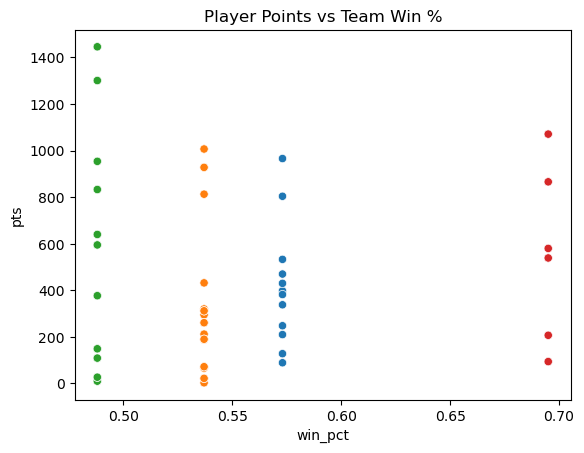

In [270]:
joined_df['win_pct'] = pd.to_numeric(joined_df['win_pct'], errors='coerce')
joined_df['pts'] = pd.to_numeric(joined_df['pts'], errors='coerce')

# Drop any rows missing values
filtered_df = joined_df.dropna(subset=['win_pct', 'pts'])

# Plot using the filtered data
sns.scatterplot(data=filtered_df, x='win_pct', y='pts', hue='team', legend=False)
plt.title('Player Points vs Team Win %')
plt.show()


### Final Reflection and Ethical Considerations

Throughout this project I explored how NBA performance metrics, team standings, and individual game results can be extracted, cleansed, merged, and analyzed using Python and SQL. The process involved several important steps: locating reliable datasets (like API data from balldontlie.io), cleaning and transforming raw data, mapping inconsistent fields (like team abbreviations), creating an SQLite database, performing SQL joins, and finally visualizing insights using pandas and matplotlib.

One important technical challenge was making sure there was compatibility between datasets that used different formats for teams. I resolved this by building a custom mapping dictionary to standardize team names across all sources. Also, missing values such as 'TOT' for players traded mid-season were handled with care to preserve data integrity. SQL joins allowed me to combine player performance, team success, and game-level outcomes in a way that would show deeper trends such as how individual stars contribute to team win percentages.

 **What I Learned**: This project showed me the importance of consistent naming conventions and schema alignment when working with multiple data sources. I also gained hands-on experience with RESTful APIs, SQLite, and data wrangling techniques like fuzzy matching and conditional mapping. Debugging SQL queries based on column mismatches was a really valuable learning moment for me, as was iterating through data visualization steps to find the clearest story.


### Ethical Implications

Data cleansing is important but carries ethical responsibilities. It’s tempting to remove outliers or fill in missing values without considering the impact, but this can lead to biased or misleading results. For example, excluding 'TOT' values could misrepresent a player's season-long impact, especially if they played important roles across multiple teams. Ethical data practices mean documenting how and why changes are made to make sure that analyses remain transparent and reproducible.

In the context of sports analytics, fairness also extends to how performance data is interpreted. Highlighting stats without context such as ignoring injuries or team dynamics can lead to unfair assessments of players. Data scientists have a duty to avoid drawing overconfident conclusions from cleaned but imperfect data.